# SPRINT 11: Visualització de Dades amb Python i Power BI

## NIVELL 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [69]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import mysql.connector
import pandas as pd

In [71]:
# conexió al database
conexio = mysql.connector.connect(
        host = 'localhost',
        user = 'root',
        password = 'Alamedas.789',
        port = 3306,
        database = 'sprint_4'
    )  

# obtenir el nom de les taules
taules = pd.read_sql('SHOW TABLES', conexio)

# diccionari per a guardar els dataframes
dfs = {}

# carrego les taules del database de SQL i li asigno els valors al diccionari
# taules.iloc[:,0] pren el nom de les taules
for taula_nom in taules.iloc[:,0]:
    # carrega la taula en un dataframe
    df = pd.read_sql(f"SELECT * FROM {taula_nom}\n", conexio)
    # guarda la taula en els valors y taula_nom en les claus
    dfs[taula_nom]=df
    print(f" - {taula_nom} carregada: {len(df)} rows")

conexio.close()
print("\n conexion cerrada.")

companies = dfs['companies']
credit_cards = dfs['credit_cards']
card_status = dfs['estat_targetes']
products = dfs['products']
transactions = dfs['transactions']
transactions_products = dfs['transactions_products']
users = dfs['users']

C:\Users\marco\AppData\Local\Temp\ipykernel_47588\249029154.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  taules = pd.read_sql('SHOW TABLES', conexio)
C:\Users\marco\AppData\Local\Temp\ipykernel_47588\249029154.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {taula_nom}\n", conexio)


 - companies carregada: 100 rows
 - credit_cards carregada: 5000 rows
 - estat_targetes carregada: 5000 rows
 - products carregada: 100 rows
 - transactions carregada: 100000 rows
 - transactions_products carregada: 253391 rows
 - users carregada: 5000 rows

 conexion cerrada.


2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

- Una variable numérica

Histograma del preu dels productes

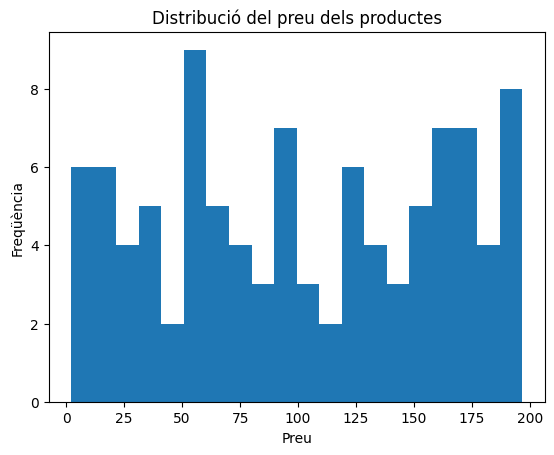

In [73]:
products['price'].plot.hist(bins = 20)
plt.xlabel('Preu')
plt.ylabel('Freqüència')
plt.title('Distribució del preu dels productes')
plt.show();

Boxplot del preu dels productes

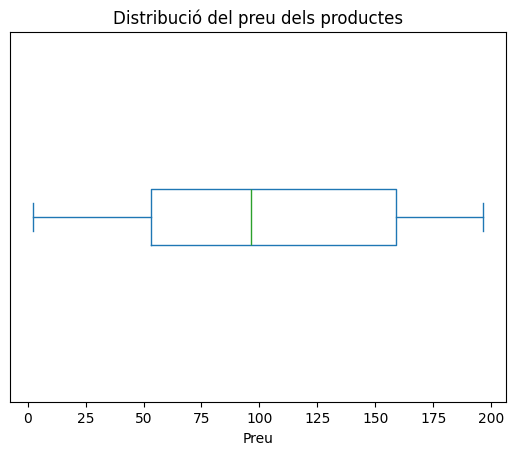

In [74]:
products['price'].plot.box(vert=False)

plt.xlabel('Preu')
plt.yticks([])

plt.title('Distribució del preu dels productes')
plt.show()

- Dues variables numèriques

,price,weight
price,1.000000,0.105431
weight,0.105431,1.000000


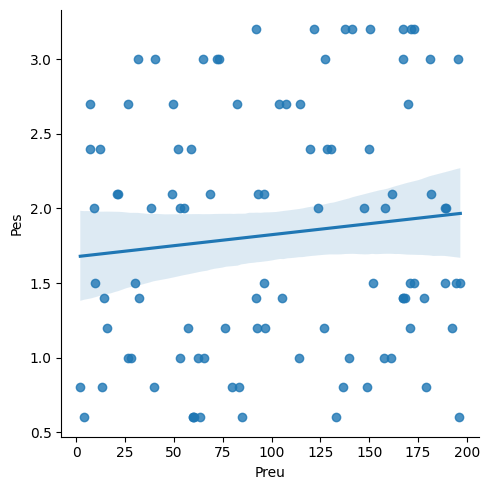

In [75]:
products['weight'] = pd.to_numeric(products['weight'], errors='coerce')
g = sns.lmplot(data=products, x='price', y='weight')
g.set_axis_labels('Preu', 'Pes')
products[['price', 'weight']].corr()

Existeix una associació lineal positiva molt feble entre el preu i el pes dels productes; la correlació lineal sembla pròxima a zero.
Encara que el model lineal mostra una lleugera tendència creixent, la dispersió de les dades és alta i la correlació (r ≈ 0.10) indica que el preu explica molt poc la variabilitat del pes. En la pràctica, el preu no és un bon predictor del pes.

- Una variable categòrica

Barres amb la quantitat de companyies per països

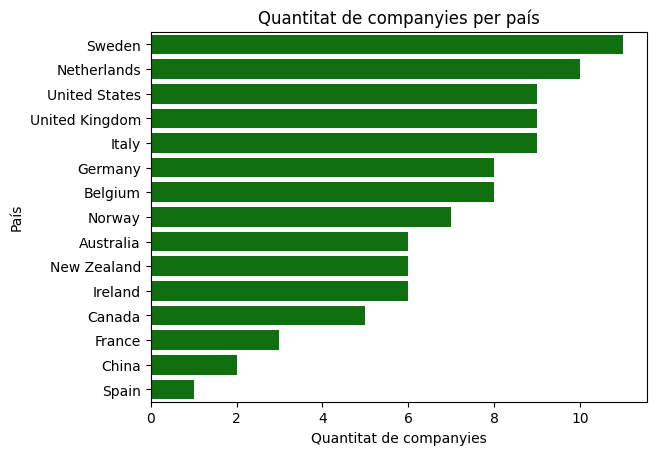

In [76]:
sns.countplot(data=companies, y='country', color='green', order=companies['country'].value_counts().index, width=0.8)

plt.xlabel('Quantitat de companyies')
plt.ylabel('País')
plt.title('Quantitat de companyies per país')

plt.show()

Diagrama sectors amb l'estat de les targetes

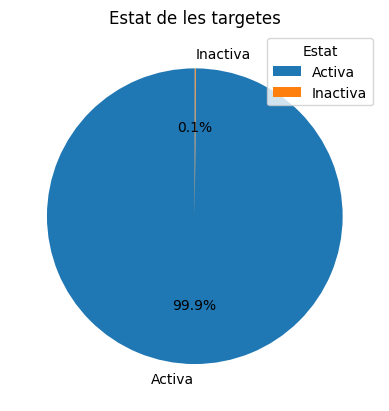

In [77]:
status_counts = card_status['estat'].value_counts()

plt.pie(
    status_counts,
    labels=status_counts.index,
    startangle=90,
    autopct='%1.1f%%' # per afegir el porcentatge
)

plt.title('Estat de les targetes')
plt.legend(title='Estat',loc='best')
plt.show()

- Dues variables categòriques

Heatmap usuaris per país i ciutat

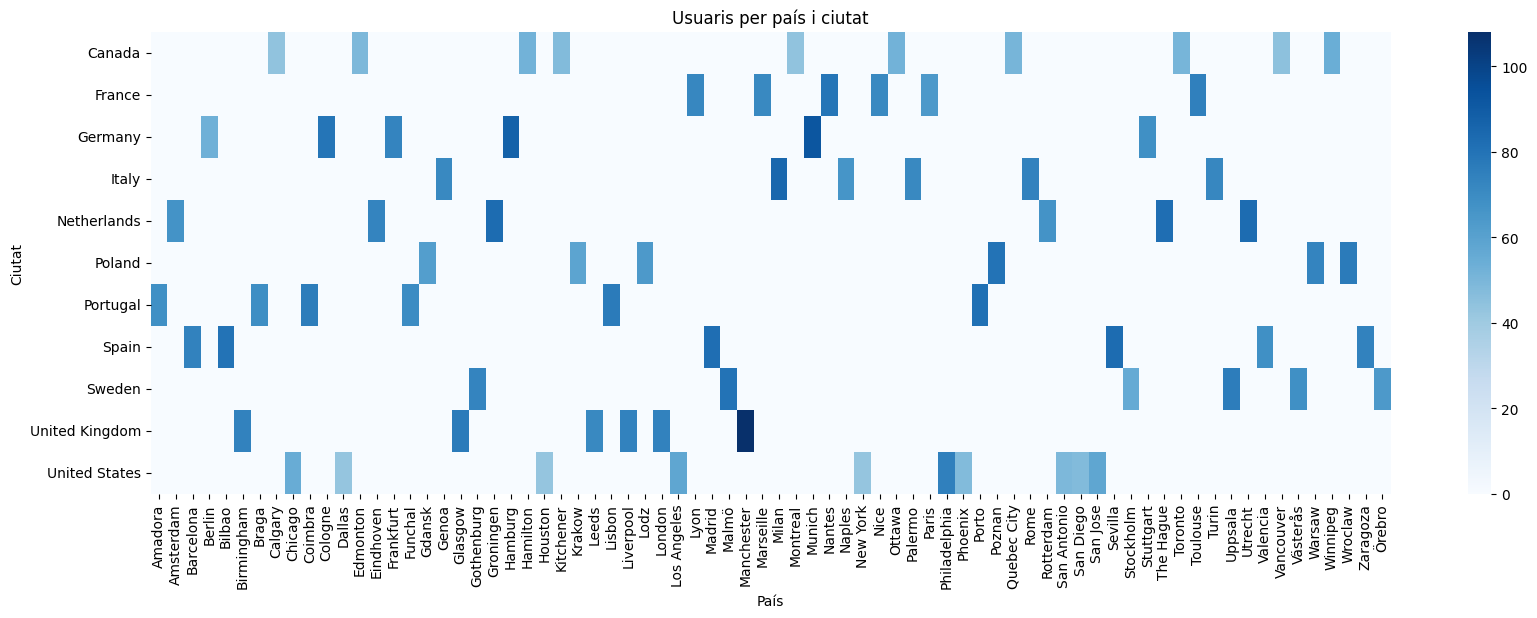

In [78]:
tabla = pd.crosstab(users['country'], users['city'])

plt.figure(figsize=(20,6))
sns.heatmap(tabla, cmap="Blues", cbar=True)
plt.title("Usuaris per país i ciutat")
plt.ylabel("Ciutat")
plt.xlabel("País")
plt.show()

El gràfic representa la distribució dels usuaris segons el país de procedència i, per a cada país, el nombre d'usuaris de les diferents ciutats. Les zones amb un color blau més intens corresponen a les ciutats que concentren un major volum d'usuaris.

- Una variable categòrica i una numèrica

Barres amb l'import mitjà per estat de la transacció

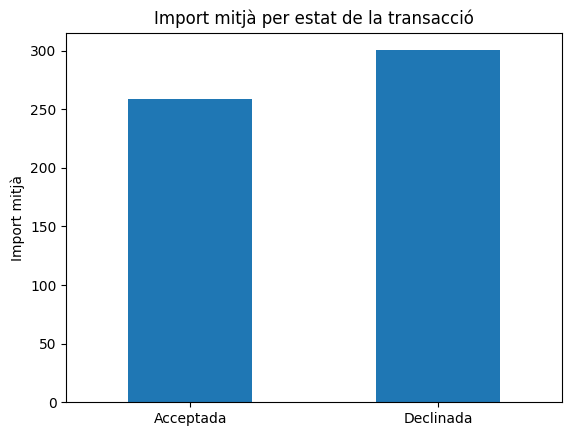

In [79]:
ax = (
    transactions
    .groupby("declined")["amount"]
    .mean()
    .rename(index={0: "Acceptada", 1: "Declinada"})
    .plot.bar(rot=0)
)

ax.set_title('Import mitjà per estat de la transacció')
ax.set_xlabel('')
ax.set_ylabel('Import mitjà');

Barres amb el total de compres per país unint dues taules

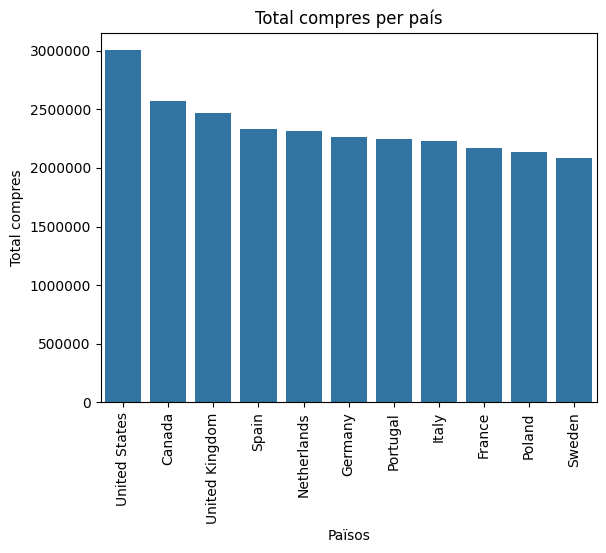

In [80]:
paisos_mes_compres = pd.merge(transactions,users, left_on= 'user_id', right_on = 'id')
paisos_mes_compres1=paisos_mes_compres[paisos_mes_compres['declined']==0].groupby('country')[['amount']].sum().sort_values(by='amount', ascending=False).reset_index()
sns.barplot(data=paisos_mes_compres1, x='country', y='amount', errorbar=None)
plt.xlabel('Països')
plt.ylabel('Total compres')
plt.title('Total compres per país')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y') # perquè et mostra els número en format normal
plt.show()

- Tres variables combinades

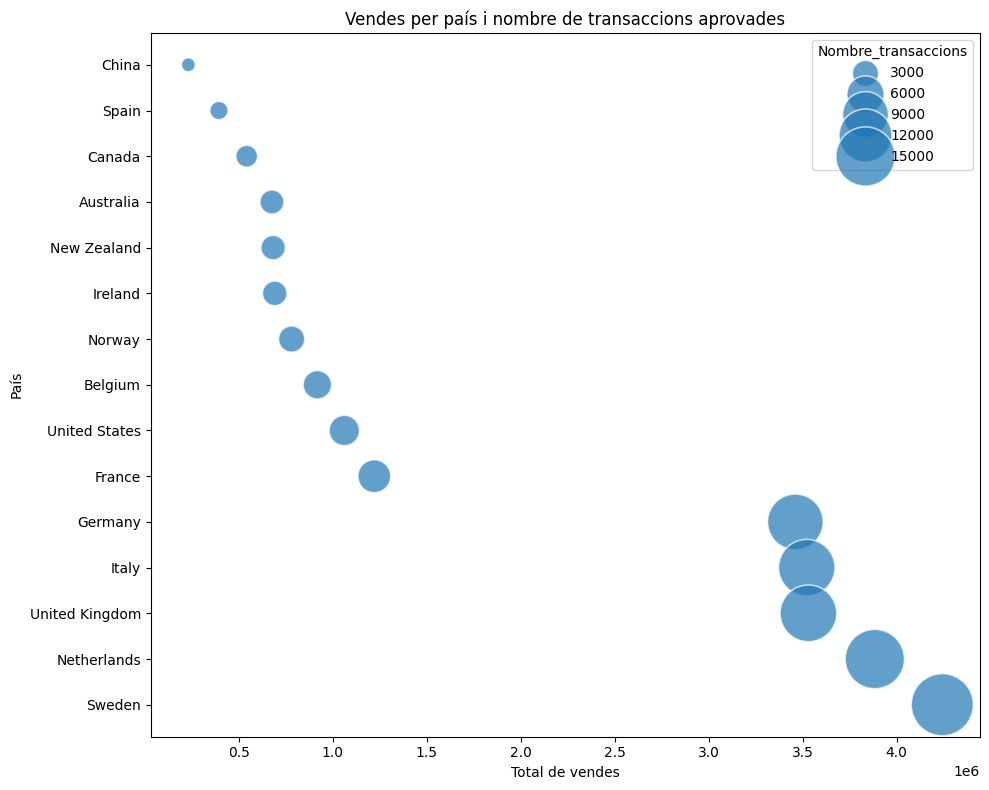

In [81]:
df_pais = pd.merge(transactions, companies, left_on= 'business_id', right_on= 'company_id')

df_pais_filtrado = (
    df_pais[df_pais['declined'] == 0]
    .groupby('country')
    .agg(
        total_amount=('amount', 'sum'),
        Nombre_transaccions=('amount', 'count')
    )
    .reset_index()
    .sort_values('total_amount')
)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_pais_filtrado,
    x='total_amount',
    y='country',
    size='Nombre_transaccions',
    sizes=(100, 2000),
    alpha=0.7
)

plt.xlabel('Total de vendes')
plt.ylabel('País')
plt.title('Vendes per país i nombre de transaccions aprovades')
plt.tight_layout()
plt.show()

El gràfic representa el volum de vendes per país, mentre que la mida de les bombolles indica el nombre total de transaccions realitzades. Les dades evidencien una correlació positiva entre aquestes dues magnituds, de manera que els països amb un volum de vendes més alt són també els que concentren un major nombre de transaccions. Destaquen especialment United Kingdom, Sweden i Netherlands, que lideren ambdós indicadors.

- Un pairplot

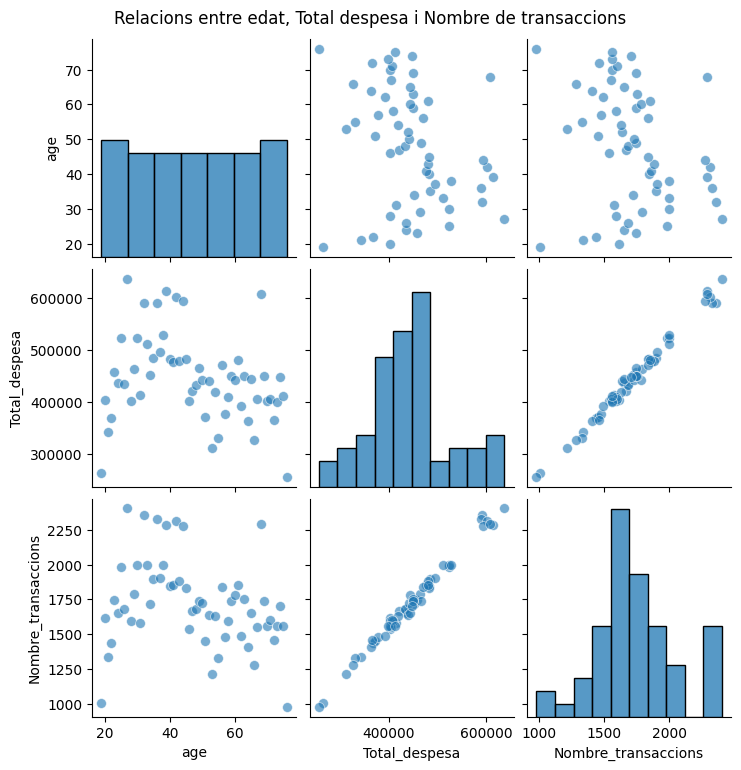

In [82]:
# Càlcul de l'edat

df = pd.merge(
    transactions,
    users,
    left_on='user_id',
    right_on='id'
)

df = df[df['declined'] == 0]

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

today = pd.Timestamp.today()

df['age'] = ((today - df['birth_date']).dt.days // 365)

despesa_per_tram_edat = (
    df.groupby('age').
    agg(Total_despesa=("amount", "sum"),
        Nombre_transaccions=("id_x", "count")).
        reset_index().
        sort_values("age")
)

sns.pairplot(
    despesa_per_tram_edat,
    vars=['age','Total_despesa', 'Nombre_transaccions'],
    kind='scatter',
    diag_kind='hist',  # histograma en la diagonal
    plot_kws={'alpha':0.6, 's':50}  # transparència i tamany de punts
)
plt.suptitle('Relacions entre edat, Total despesa i Nombre de transaccions', y=1.02)
plt.show()

En aquest pairplot, la diagonal mostra la distribució de cada variable de manera individual, mentre que la resta de gràfics representen les relacions entre parells de variables. L'anàlisi indica que l'edat presenta una distribució relativament homogènia. Pel que fa a la relació entre l'edat i el nombre de transaccions, no s'identifica cap patró clar que suggereixi una associació significativa entre ambdues variables. De la mateixa manera, tampoc s'observa una relació evident entre l'edat i la despesa total, fet que indica que un increment de l'edat no implica necessàriament una major despesa. En canvi, la relació entre el nombre de transaccions i l'import total gastat mostra una forta correlació positiva de caràcter lineal, un resultat coherent amb el fet que un major nombre d'operacions acostuma a traduir-se en una despesa acumulada més elevada.

- Dates

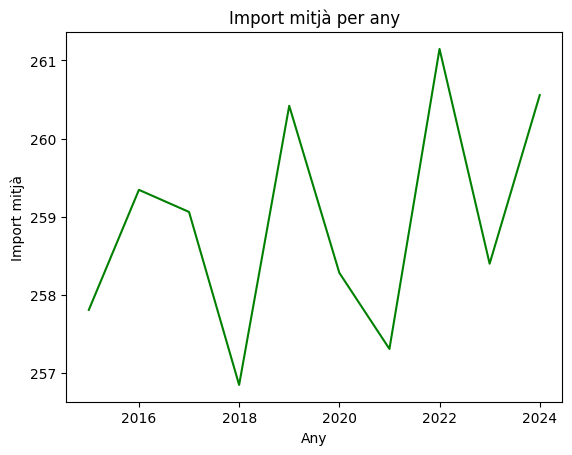

In [83]:
amount_per_any = (
    transactions[transactions['declined'] == 0]
    .groupby(transactions['timestamp'].dt.year)['amount']
    .mean()
    .reset_index()
)

sns.lineplot(data= amount_per_any,x='timestamp',y='amount', color='green')
plt.xlabel('Any')
plt.ylabel('Import mitjà')
plt.title('Import mitjà per any')
plt.show()

Mostrem també amb un gràfic de barres l'evolució temporal de l'import mitjà, ja que així podem observar com la variació entre els diferents anys és força petita.

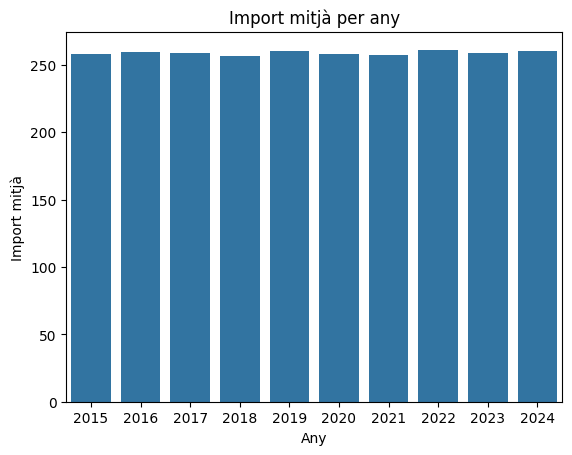

In [84]:
sns.barplot(data= amount_per_any,x='timestamp',y='amount')
plt.xlabel('Any')
plt.ylabel('Import mitjà')
plt.title('Import mitjà per any')
plt.show()

## NIVELL 2

1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

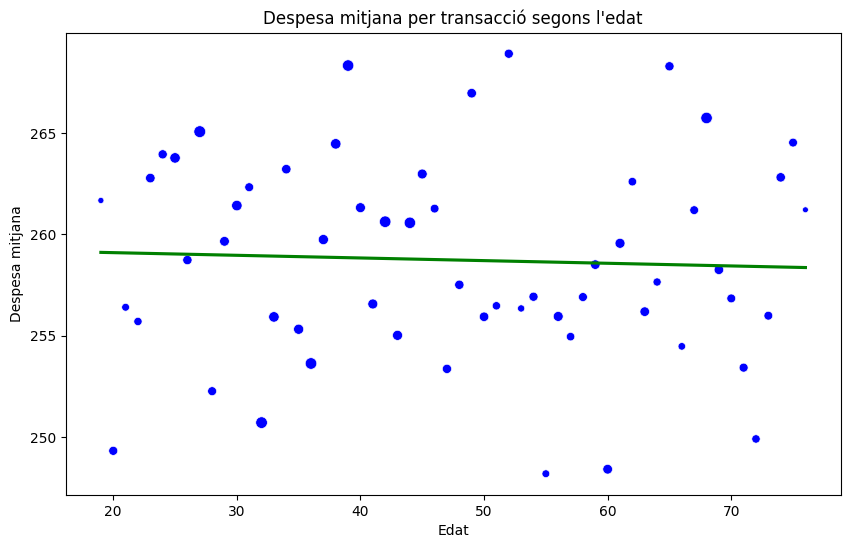

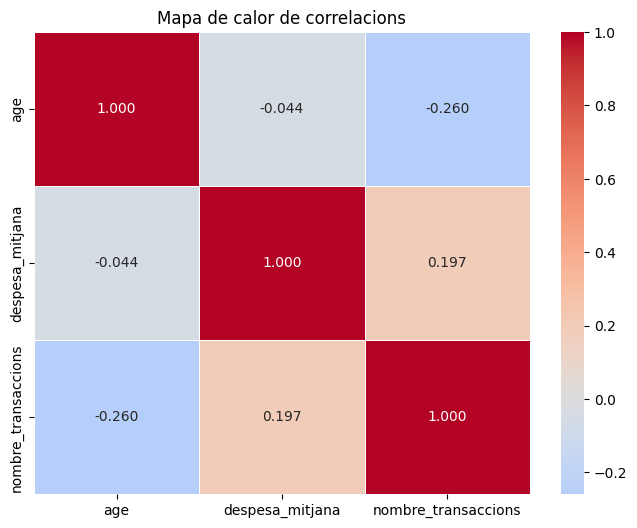

In [85]:
df = pd.merge(
    transactions,
    users,
    left_on='user_id',
    right_on='id'
)

df = df[df['declined'] == 0]

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')

today = pd.Timestamp.today()

df['age'] = ((today - df['birth_date']).dt.days // 365)

df5 = (
    df.groupby('age').
    agg(despesa_mitjana=('amount', 'mean'),
        nombre_transaccions=('id_x', 'count')).
        reset_index().
        sort_values('age')
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='age',
    y='despesa_mitjana',
    size='nombre_transaccions',
    data=df5,
    legend=False,
    color='blue'
)

sns.regplot(
    x='age',
    y='despesa_mitjana',
    data=df5,
    scatter=False,
    color='green',
    ci=None
)

plt.title("Despesa mitjana per transacció segons l'edat")
plt.xlabel('Edat')
plt.ylabel('Despesa mitjana')
plt.show()


df5.corr()

# 1. Calcular la matriu de correlació
corr_matrix = df5.corr()

# 2. Configurar el gràfic
plt.figure(figsize=(8, 6))

# 3. Crear el heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,      # Mostra els números dins dels quadres
    cmap='coolwarm', # Escala de colors (blau per al negatiu, vermell per al positiu)
    fmt='.3f',       # Format de 3 decimals
    center=0,        # El color blanc serà el 0
    linewidths=0.5   # Espai entre quadres
)

plt.title('Mapa de calor de correlacions')
plt.show()

A partir dels valors i de la intensitat dels colors del mapa de correlacions, es poden extreure les conclusions següents:

Edat vs. Despesa mitjana (-0,044): La correlació és pràcticament nul·la, tal com reflecteix el color neutre del gràfic. Per tant, no s'observa cap relació significativa entre l'edat dels usuaris i la despesa mitjana per compra, fet que indica que l'edat no és un factor determinant del tiquet mitjà.
Edat vs. Nombre de transaccions (-0,260): Aquesta és la correlació de major magnitud entre les variables analitzades. El signe negatiu i la tonalitat blavosa indiquen una relació inversa moderada: a mesura que augmenta l'edat, el nombre de transaccions tendeix a disminuir.
Despesa mitjana vs. Nombre de transaccions (0,197): S'identifica una correlació positiva feble entre aquestes variables. Això podria suggerir que els usuaris que realitzen més compres tendeixen a efectuar transaccions d'un import lleugerament superior. Tanmateix, la intensitat de la relació és reduïda i no permet establir una associació concloent.

En conjunt, els resultats indiquen que l'edat té una influència limitada sobre els patrons de despesa, mentre que presenta una relació moderadament negativa amb la freqüència de compra. Per la seva banda, la despesa mitjana i el nombre de transaccions mostren una associació feble i poc rellevant des del punt de vista pràctic.

2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

El coeficient de correlació és -0.26


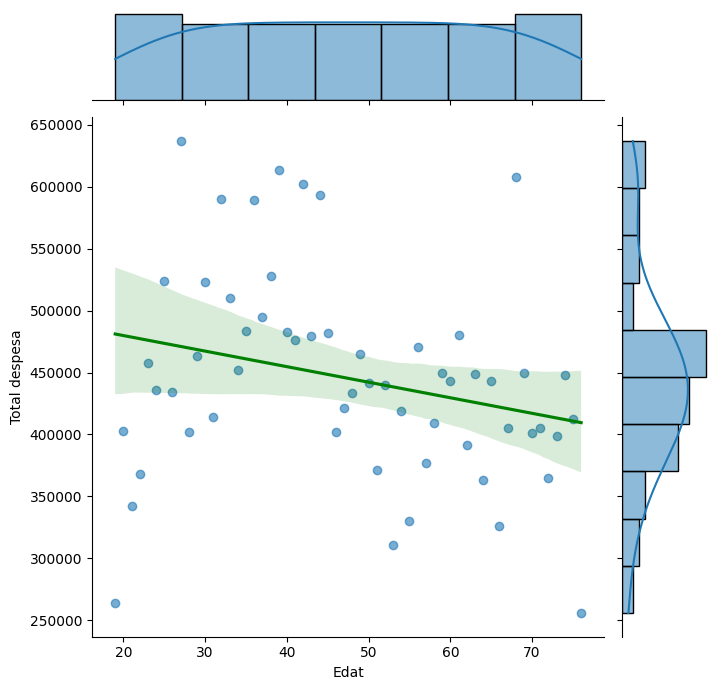

In [86]:
g = sns.jointplot(x = 'age', y = 'Total_despesa', data = despesa_per_tram_edat,   
    kind='reg',      # scatter + línia de regressió
    height=7,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'green'})

g.set_axis_labels('Edat', 'Total despesa')

x = despesa_per_tram_edat['age']
y = despesa_per_tram_edat['Total_despesa']

r = np.corrcoef(x, y)[0, 1].round(2)
print(f'El coeficient de correlació és {r}')

S'observa una correlació negativa feble entre l'edat i la despesa total (r=−0.26). Encara que els clients de major edat tendeixen a gastar lleugerament menys, la relació és poc intensa i l'edat, per si sola, no constitueix un bon predictor de la despesa total.